### [Market Basket Analysis](https://python.plainenglish.io/market-basket-analysis-with-python-019d99bee436)

> *Market Basket Analysis (MBA)* is a widely used data mining technique that explores relationships between items in large sets of transaction data to identify patterns of co-occurrence.

In [1]:
import warnings
warnings.filterwarnings("ignore")

colab = True

import sys
if "google.colab" not in sys.modules:
  colab = False

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:")
display(path)

100%|██████████| 197M/197M [00:05<00:00, 38.8MB/s]

Extracting files...


Path to dataset files:


'/root/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1'

In [3]:
import pandas as pd

# Load the data
orders = pd.read_csv(f"{path}/orders.csv") #provide the path
products = pd.read_csv(f"{path}/products.csv")
order_products = pd.read_csv(f"{path}/order_products__prior.csv")

# Merge to get product names
merged = order_products.merge(products, on="product_id", how="left")

# Optional: limit for speed
merged = merged[merged["order_id"] < 5000]

# Create baskets (list of items per order_id)
baskets = merged.groupby("order_id")["product_name"].apply(list).tolist()

display(baskets[1:3])

[['Total 2% with Strawberry Lowfat Greek Strained Yogurt',
  'Unsweetened Almondmilk',
  'Lemons',
  'Organic Baby Spinach',
  'Unsweetened Chocolate Almond Breeze Almond Milk',
  'Organic Ginger Root',
  'Air Chilled Organic Boneless Skinless Chicken Breasts',
  'Organic Ezekiel 49 Bread Cinnamon Raisin'],
 ['Plain Pre-Sliced Bagels',
  'Honey/Lemon Cough Drops',
  'Chewy 25% Low Sugar Chocolate Chip Granola',
  'Oats & Chocolate Chewy Bars',
  "Kellogg's Nutri-Grain Apple Cinnamon Cereal",
  'Nutri-Grain Soft Baked Strawberry Cereal Breakfast Bars',
  "Kellogg's Nutri-Grain Blueberry Cereal",
  'Tiny Twists Pretzels',
  'Traditional Snack Mix',
  'Goldfish Cheddar Baked Snack Crackers',
  'Original Orange Juice',
  'Sugarfree Energy Drink',
  'Energy Drink']]

In [4]:
import itertools
import random
import time
import tracemalloc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Algorithms
# -----------------------------

# Brute-force method
def brute_force_C2(baskets, support_threshold):
    C2 = {}
    for basket in baskets:
        for pair in itertools.combinations(basket, 2):
            key = frozenset(pair)
            C2[key] = C2.get(key, 0) + 1
    return {k: v for k, v in C2.items() if v >= support_threshold}

# Apriori Algorithm
def apriori_C2(baskets, support_threshold):
    # Count individual items
    C1 = {}
    for basket in baskets:
        for item in basket:
            key = frozenset([item])
            C1[key] = C1.get(key, 0) + 1
    L1 = {k for k, v in C1.items() if v >= support_threshold}

    # Generate valid 2-itemsets from L1
    C2_items = set(a.union(b) for a in L1 for b in L1 if a != b)

    #Count valid 2-itemsets
    C2 = {}
    for basket in baskets:
        for pair in itertools.combinations(basket, 2):
            key = frozenset(pair)
            if key in C2_items:
                C2[key] = C2.get(key, 0) + 1
    return {k: v for k, v in C2.items() if v >= support_threshold}

# PCY Algorithm (Park-Chen-Yu)
def pcy_C2(baskets, support_threshold, max_hash=10000):
    # First pass: hash all 2-itemsets
    H = np.zeros((max_hash,), dtype=np.int32)
    for basket in baskets:
        for pair in itertools.combinations(basket, 2):
            key = frozenset(pair)
            h = hash(key) % max_hash
            H[h] += 1
    H_good = set(np.where(H >= support_threshold)[0])
    del H

    # Count individual items
    C1 = {}
    for basket in baskets:
        for item in basket:
            key = frozenset([item])
            C1[key] = C1.get(key, 0) + 1
    L1 = {k for k, v in C1.items() if v >= support_threshold}

    # Generate candidate 2-itemsets
    C2_items = set(a.union(b) for a in L1 for b in L1 if a != b)

    # Second pass: count filtered itemsets
    C2 = {}
    for basket in baskets:
        for pair in itertools.combinations(basket, 2):
            key = frozenset(pair)
            h = hash(key) % max_hash
            if h in H_good and key in C2_items:
                C2[key] = C2.get(key, 0) + 1
    return {k: v for k, v in C2.items() if v >= support_threshold}

In [5]:
brute_result = brute_force_C2(baskets, support_threshold=50)
apriori_result = apriori_C2(baskets, support_threshold=50)
pcy_result = pcy_C2(baskets, support_threshold=50)

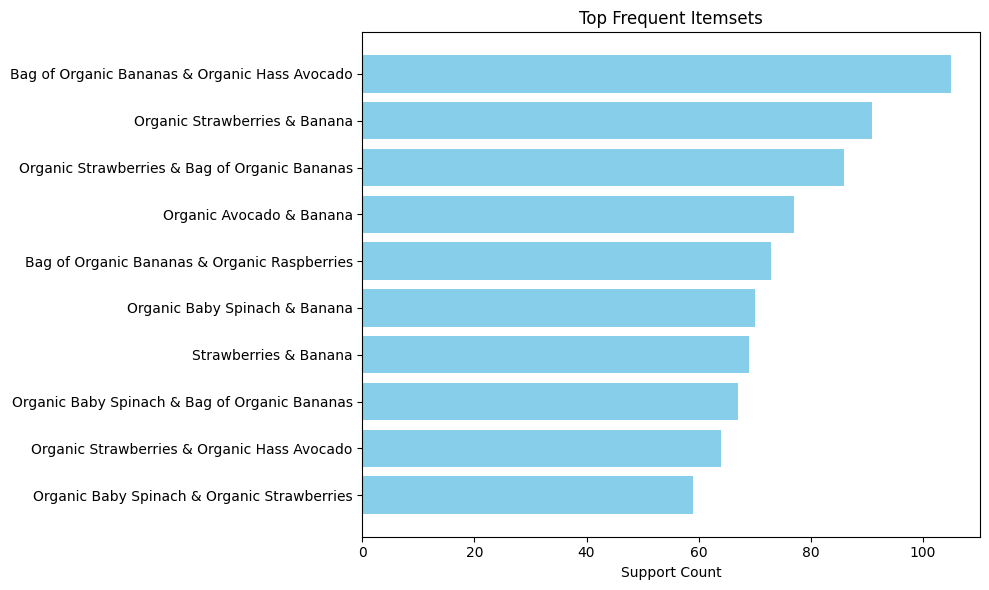

In [6]:
import matplotlib.pyplot as plt

# Top 10 itemsets by frequency
def plot_top_itemsets(frequent_itemsets, top_n=10, title="Top Frequent Itemsets"):
    sorted_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:top_n]
    labels = [' & '.join(list(k)) for k, v in sorted_items]
    values = [v for k, v in sorted_items]

    plt.figure(figsize=(10, 6))
    plt.barh(labels, values, color='skyblue')
    plt.xlabel("Support Count")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_itemsets(brute_result)

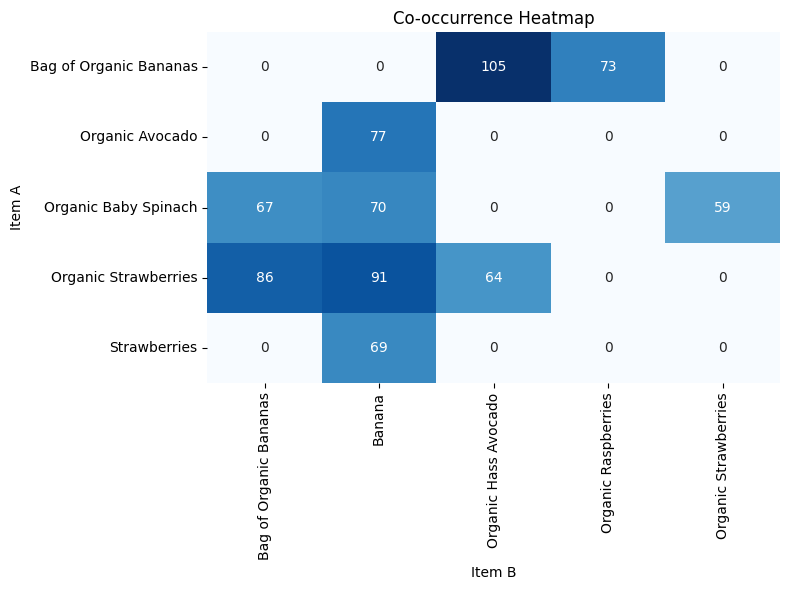

In [7]:
def itemset_heatmap(frequent_itemsets, top_n=10):
    top_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:top_n]
    item_pairs = [list(k) for k, v in top_items if len(k) == 2]
    counts = [v for k, v in top_items if len(k) == 2]

    df = pd.DataFrame(item_pairs, columns=['Item A', 'Item B'])
    df['Count'] = counts
    pivot = df.pivot(index="Item A", columns="Item B", values="Count")

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot.fillna(0).astype(int), annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Co-occurrence Heatmap")
    plt.tight_layout()
    plt.show()

itemset_heatmap(brute_result)

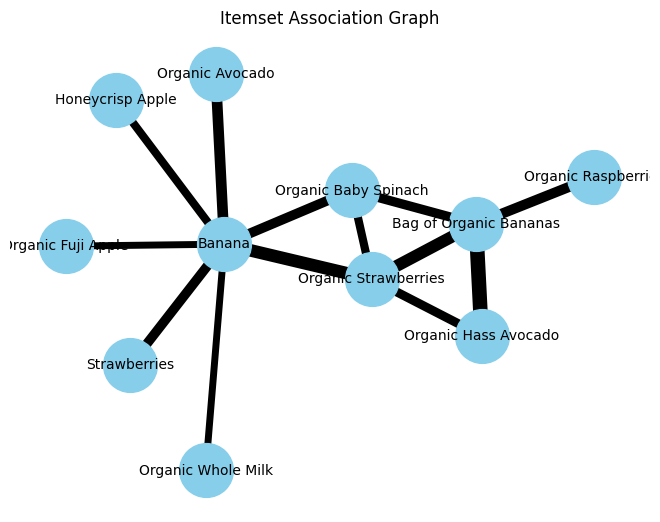

In [8]:
import networkx as nx

def plot_itemset_graph(frequent_itemsets, min_support=50, top_n=20):
    G = nx.Graph()
    top_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:top_n]

    for itemset, support in top_items:
        if len(itemset) == 2 and support >= min_support:
            a, b = list(itemset)
            G.add_edge(a, b, weight=support)

    pos = nx.spring_layout(G, seed=42)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1500,
            width=[w / 10 for w in edge_weights], font_size=10)
    plt.title("Itemset Association Graph")
    plt.show()

plot_itemset_graph(apriori_result)

,Method,Time (s),Memory (MB),Frequent Itemsets
0,Brute-force,2.3666,69.94,9
1,Apriori,1.9547,4.15,9
2,PCY,6.4583,3.62,9


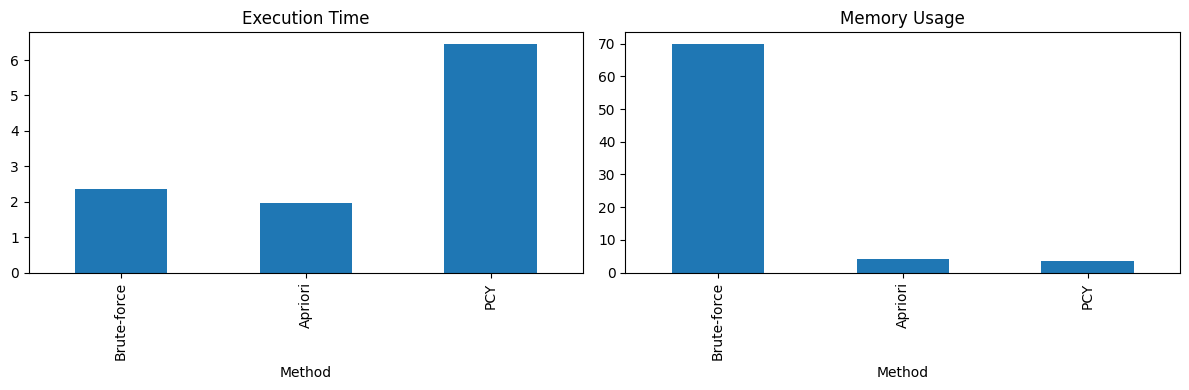

In [9]:
def measure_performance(method, baskets, support_threshold):
    tracemalloc.start()
    start_time = time.time()
    result = method(baskets, support_threshold)
    elapsed = time.time() - start_time
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return {
        "Time (s)": round(elapsed, 4),
        "Memory (MB)": round(peak / (1024 * 1024), 2),
        "Frequent Itemsets": len(result)
    }

support_threshold = 60

results = {
    "Brute-force": measure_performance(brute_force_C2, baskets, support_threshold),
    "Apriori": measure_performance(apriori_C2, baskets, support_threshold),
    "PCY": measure_performance(pcy_C2, baskets, support_threshold)
}

# Create a comparison DataFrame
df = pd.DataFrame.from_dict(results, orient='index').reset_index().rename(columns={'index': 'Method'})
df = df[['Method', 'Time (s)', 'Memory (MB)', 'Frequent Itemsets']]

# -----------------------------
# Display Results
# -----------------------------
display(df)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.plot(kind='bar', x='Method', y='Time (s)', ax=axes[0], legend=False, title="Execution Time")
df.plot(kind='bar', x='Method', y='Memory (MB)', ax=axes[1], legend=False, title="Memory Usage")
plt.tight_layout()
plt.show()